# 03 - Comparacion y metricas post-inferencia

Usa este notebook **despues** de generar predicciones en el notebook
`01_walkthrough_nowcasting_practico.ipynb` (paso 3), o directamente con el script:

```bash
python scripts/run_inference_from_list.py scripts/sequences_example.txt --stage all --device auto
```

Aqui es donde **medimos**. Calculamos las metricas **una sola vez** sobre las predicciones
guardadas en `outputs/predictions/` y comparamos persistencia, EarthFormer y CasCast con
exactamente los mismos numeros y las mismas figuras.

> El notebook 01 *genera y mira* predicciones. Este notebook 03 *mide y compara*. No repetimos
> el calculo de metricas entre ambos.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from course_utils.data import SAMPLE_FILES, get_paths, load_sample, split_sequence
from course_utils.evaluation import (
    available_prediction_models,
    evaluate_predictions,
    load_prediction_for_model,
    save_evaluation_tables,
)
from course_utils.plotting import plot_event_grid, plot_target_prediction_panel
from course_utils.palette import apply_course_style

apply_course_style()
paths = get_paths(PROJECT_ROOT)
print(f"Proyecto: {paths.root}")
print(f"Predicciones: {paths.prediction_dir}")

Proyecto: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab
Predicciones: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab/outputs/predictions


## 1. Que predicciones existen

La comparacion lee estas carpetas dentro de `outputs/predictions/`:

- `persistence/`
- `earthformer/`
- `cascast/`
- `model/` (compatibilidad anterior)

Solo se evaluan los modelos cuyo `.npy` existe para cada caso; el resto se salta sin romper nada.

In [2]:
availability = []
for name in SAMPLE_FILES:
    models = available_prediction_models(name, include_persistence=True, paths=paths)
    availability.append({"sample": name, "available_models": ", ".join(models)})

pd.DataFrame(availability)

,sample,available_models
0,barranca_seq_20240426_2000_patch_04_rain_rate.npy,"persistence, earthformer, cascast"
1,barranca_seq_20240508_0600_patch_05_rain_rate.npy,"persistence, earthformer, cascast"
2,barranca_seq_20240512_0800_patch_03_rain_rate.npy,persistence
3,guaviare_seq_20240329_0700_patch_05_rain_rate.npy,persistence
4,guaviare_seq_20240329_0800_patch_03_rain_rate.npy,"persistence, earthformer, cascast"


## 2. Las metricas que usamos

Para cada tiempo de pronostico $k$ (de +5 a +60 min) comparamos la prediccion $\hat{Y}_k$
con el objetivo real $Y_k$ sobre la grilla $H\times W$.

**Metricas continuas** (sobre el valor de lluvia en mm/h):

$$
\mathrm{MAE}_k = \frac{1}{HW}\sum_{i,j}\bigl|\hat{Y}_{k,i,j}-Y_{k,i,j}\bigr|
\qquad
\mathrm{RMSE}_k = \sqrt{\frac{1}{HW}\sum_{i,j}\bigl(\hat{Y}_{k,i,j}-Y_{k,i,j}\bigr)^2}
$$

$$
\mathrm{Bias}_k = \frac{1}{HW}\sum_{i,j}\bigl(\hat{Y}_{k,i,j}-Y_{k,i,j}\bigr)
\qquad
r_k = \frac{\sum (\hat{Y}-\bar{\hat{Y}})(Y-\bar{Y})}{\sqrt{\sum(\hat{Y}-\bar{\hat{Y}})^2}\;\sqrt{\sum(Y-\bar{Y})^2}}
$$

- **MAE / RMSE**: error promedio. RMSE castiga mas los errores grandes.
- **Bias**: signo del error. Positivo = el modelo sobreestima; negativo = subestima.
- **Pearson $r$**: correlacion espacial (estructura), independiente de la escala.

**Metricas de evento** (por umbral $u$ en mm/h). Definimos lluvia si el valor $\ge u$ y contamos
aciertos $TP$, falsas alarmas $FP$ y omisiones $FN$:

$$
\mathrm{CSI} = \frac{TP}{TP+FP+FN}
\qquad
\mathrm{POD} = \frac{TP}{TP+FN}
\qquad
\mathrm{FAR} = \frac{FP}{TP+FP}
\qquad
\mathrm{F1} = \frac{2\,TP}{2\,TP+FP+FN}
$$

- **CSI** (Critical Success Index): ignora los verdaderos negativos, que dominan en radar.
- **POD**: cuanta lluvia real detectaste. **FAR**: cuantas alarmas fueron falsas.

Usamos umbrales 0.5 (ligera), 2.0 (moderada), 5.0 (fuerte) y 10.0 mm/h (intensa).
La implementacion esta en `course_utils/metrics.py`; aqui la usamos via `evaluate_predictions`.

## 3. Evaluacion completa (una sola vez)

`evaluate_predictions` recorre cada caso y cada modelo disponible y devuelve cuatro tablas:

- `continuous_all`: metricas continuas por lead time;
- `event_all`: metricas de evento por lead time y umbral;
- `per_file`: resumen por archivo;
- `overall`: resumen global por modelo.

Tambien guardamos las tablas en `outputs/evaluation/` para reutilizarlas.

In [3]:
continuous_all, event_all, per_file, overall = evaluate_predictions(paths=paths)

output_dir = paths.root / "outputs" / "evaluation"
save_evaluation_tables(continuous_all, event_all, per_file, overall, output_dir)

print("Tablas guardadas en:", output_dir)
overall

Tablas guardadas en: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab/outputs/evaluation


,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_2_mean,CSI_5_mean,CSI_10_mean
1,earthformer,1.090783,0.348561,-0.049858,0.642066,0.667038,0.314195,0.095055,0.104658
0,cascast,1.501214,0.702004,-0.283093,-0.004024,0.106177,0.002798,0.000119,0.000000
2,persistence,1.717438,0.449517,0.056092,0.376623,0.544273,0.243252,0.100940,0.074848


## 4. Resumen por archivo

Busca casos donde un modelo tenga bajo RMSE pero bajo CSI a 10 mm/h: esos son buenos ejemplos
para discutir suavizado y perdida de nucleos intensos.

In [4]:
per_file.sort_values(["sample", "RMSE_mean"])

,sample,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_2_mean,CSI_5_mean,CSI_10_mean
1,barranca_seq_20240426_2000_patch_04_rain_rate.npy,earthformer,1.659013,0.247390,-0.089735,0.381944,0.446686,0.260869,0.141444,0.074342
2,barranca_seq_20240426_2000_patch_04_rain_rate.npy,cascast,1.830591,0.499195,0.063812,0.117275,0.150802,0.008394,0.000358,0.000000
0,barranca_seq_20240426_2000_patch_04_rain_rate.npy,persistence,2.171548,0.346029,-0.020286,0.261823,0.398552,0.250179,0.137261,0.087754
4,barranca_seq_20240508_0600_patch_05_rain_rate.npy,earthformer,1.109861,0.524704,-0.134622,0.759315,0.893260,0.500818,0.069820,0.140274
5,barranca_seq_20240508_0600_patch_05_rain_rate.npy,cascast,1.924471,1.134207,-0.734317,-0.074774,0.101413,0.000000,0.000000,0.000000
3,barranca_seq_20240508_0600_patch_05_rain_rate.npy,persistence,2.109822,0.692845,0.078865,0.531172,0.887441,0.520551,0.113525,0.120020
6,barranca_seq_20240512_0800_patch_03_rain_rate.npy,persistence,2.008800,0.237560,0.125580,0.276087,0.337051,0.123346,0.120790,0.099290
7,guaviare_seq_20240329_0700_patch_05_rain_rate.npy,persistence,1.523588,0.621125,0.068376,0.296114,0.523193,0.167601,0.093174,0.027039
9,guaviare_seq_20240329_0800_patch_03_rain_rate.npy,earthformer,0.503475,0.273588,0.074784,0.784940,0.661170,0.180898,0.073902,0.099359
10,guaviare_seq_20240329_0800_patch_03_rain_rate.npy,cascast,0.748581,0.472610,-0.178776,-0.054572,0.066316,0.000000,0.000000,0.000000


## 5. Curvas por tiempo de pronostico

Las tablas anteriores promedian sobre el tiempo. Aqui miramos como evoluciona el error a medida
que el pronostico se aleja: RMSE y sesgo (continuas) y CSI a 5 mm/h (evento), una linea por modelo
promediando sobre todos los casos disponibles.

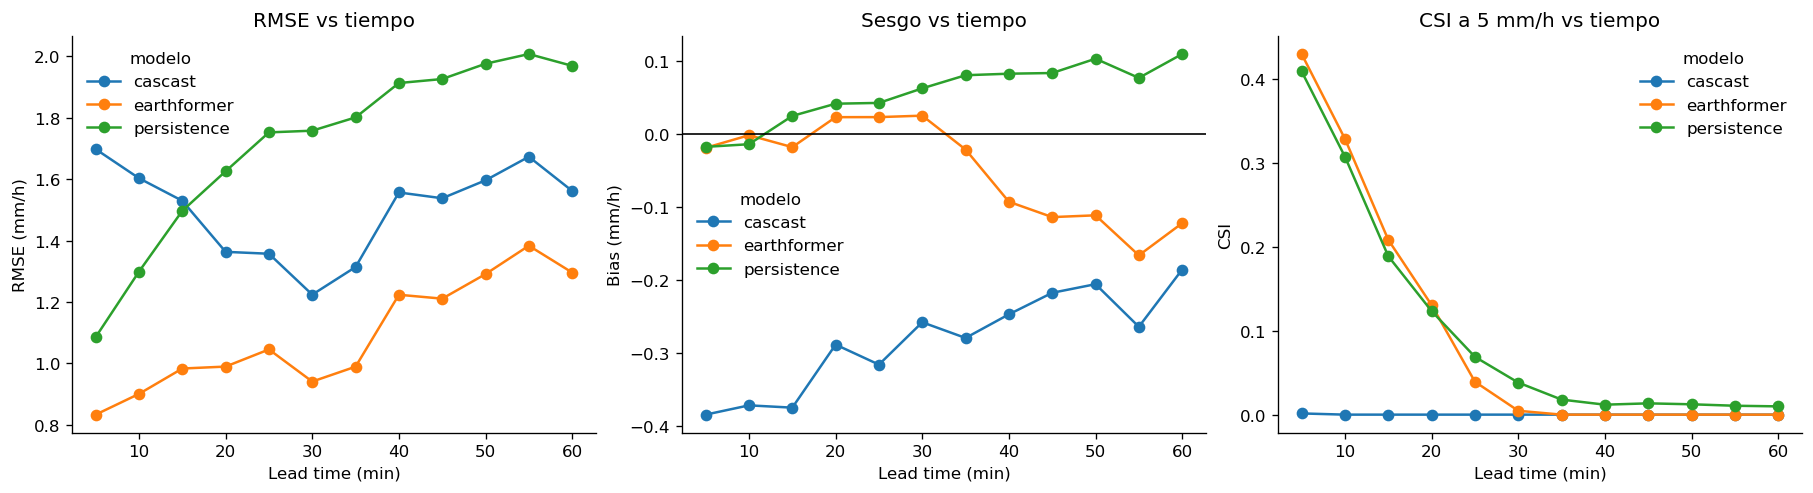

In [5]:
if continuous_all.empty:
    print("No hay predicciones evaluadas todavia.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    for model_name, g in continuous_all.groupby("model"):
        gg = g.groupby("lead_min", as_index=False)[["RMSE", "Bias"]].mean()
        axes[0].plot(gg["lead_min"], gg["RMSE"], marker="o", label=model_name)
        axes[1].plot(gg["lead_min"], gg["Bias"], marker="o", label=model_name)

    csi5 = event_all[event_all["threshold_mm_h"] == 5.0]
    for model_name, g in csi5.groupby("model"):
        gg = g.groupby("lead_min", as_index=False)["CSI"].mean()
        axes[2].plot(gg["lead_min"], gg["CSI"], marker="o", label=model_name)

    axes[0].set_title("RMSE vs tiempo")
    axes[0].set_xlabel("Lead time (min)"); axes[0].set_ylabel("RMSE (mm/h)")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("Sesgo vs tiempo")
    axes[1].set_xlabel("Lead time (min)"); axes[1].set_ylabel("Bias (mm/h)")
    axes[2].set_title("CSI a 5 mm/h vs tiempo")
    axes[2].set_xlabel("Lead time (min)"); axes[2].set_ylabel("CSI")
    for ax in axes:
        ax.legend(title="modelo")
    plt.show()

## 6. RMSE vs CSI intenso

Una comparacion util de fidelidad: a la izquierda el error promedio, arriba la habilidad para
lluvia intensa (CSI a 10 mm/h). El "mejor" modelo esta abajo-derecha solo si confundes error con
habilidad; por eso miramos ambas.

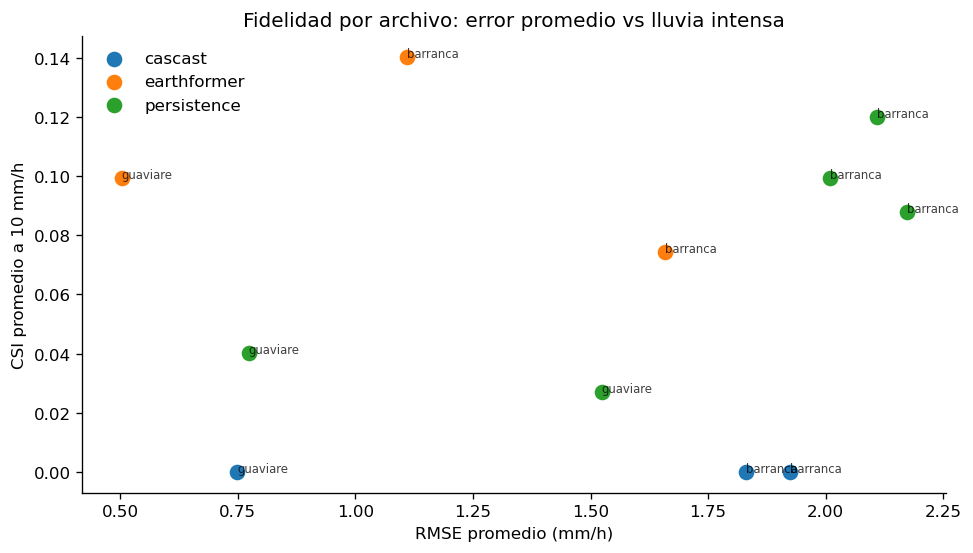

In [6]:
if per_file.empty or len(per_file["model"].unique()) == 1:
    print("Solo hay un modelo disponible. Corre la inferencia de EarthFormer/CasCast para comparar.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    for model_name, group in per_file.groupby("model"):
        ax.scatter(group["RMSE_mean"], group["CSI_10_mean"], s=70, label=model_name)
        for _, row in group.iterrows():
            ax.annotate(row["sample"].split("_seq_")[0], (row["RMSE_mean"], row["CSI_10_mean"]),
                        fontsize=7, alpha=0.75)
    ax.set_xlabel("RMSE promedio (mm/h)")
    ax.set_ylabel("CSI promedio a 10 mm/h")
    ax.set_title("Fidelidad por archivo: error promedio vs lluvia intensa")
    ax.legend()
    plt.show()

## 7. Comparacion visual en un caso

Cambia `sample_name` para mirar caso por caso. Se dibuja entrada, objetivo, prediccion y error
absoluto para cada modelo disponible.

Modelos disponibles: ['persistence', 'earthformer', 'cascast']


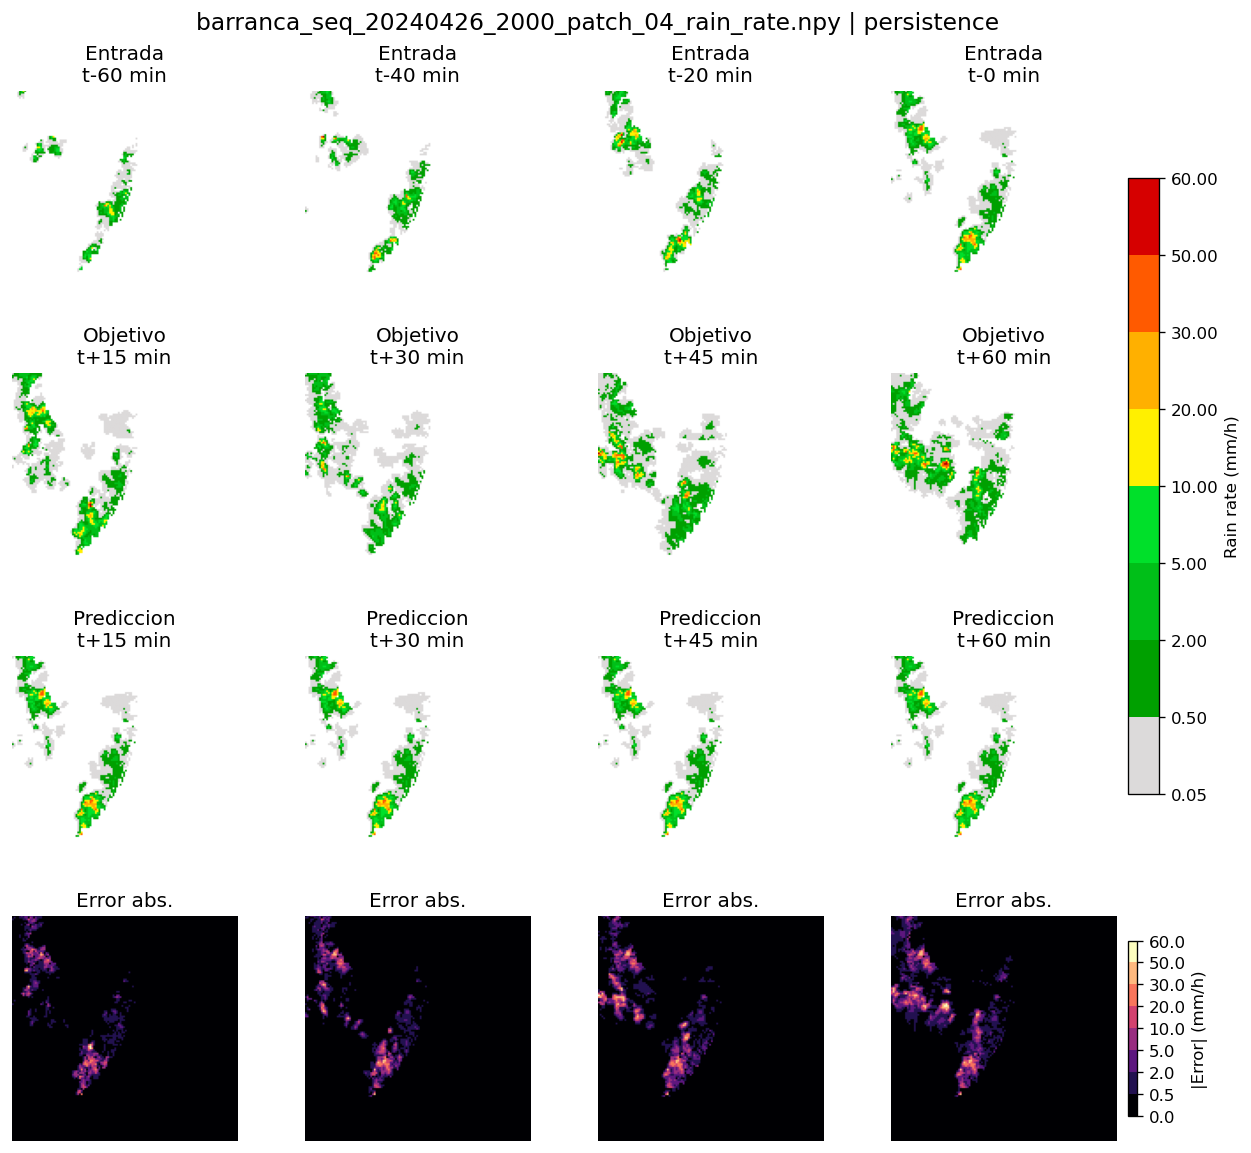

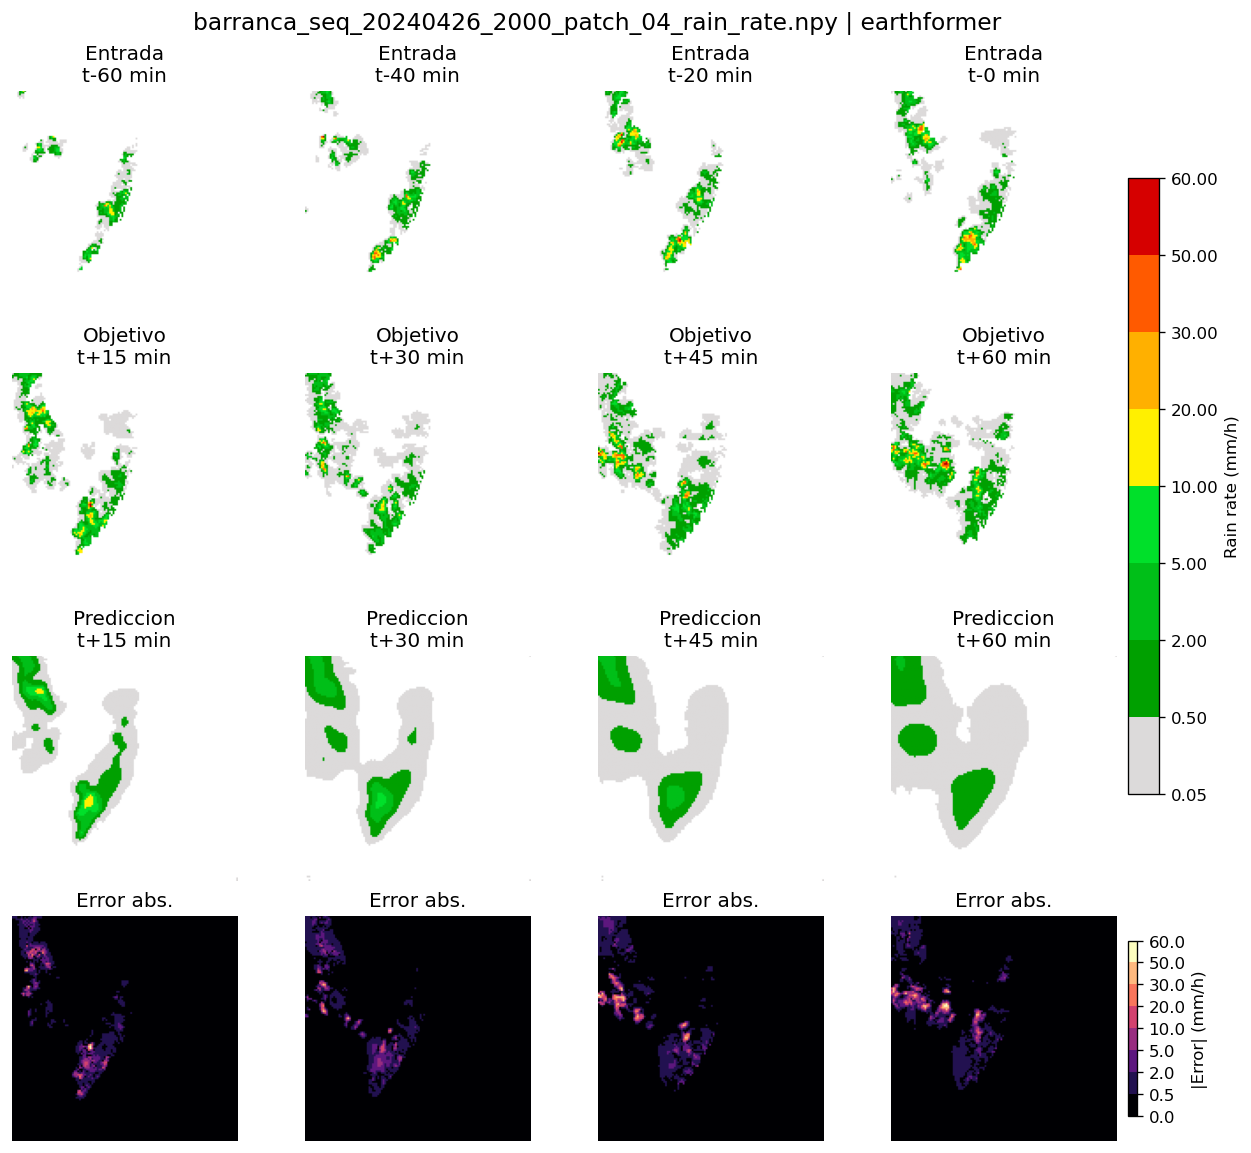

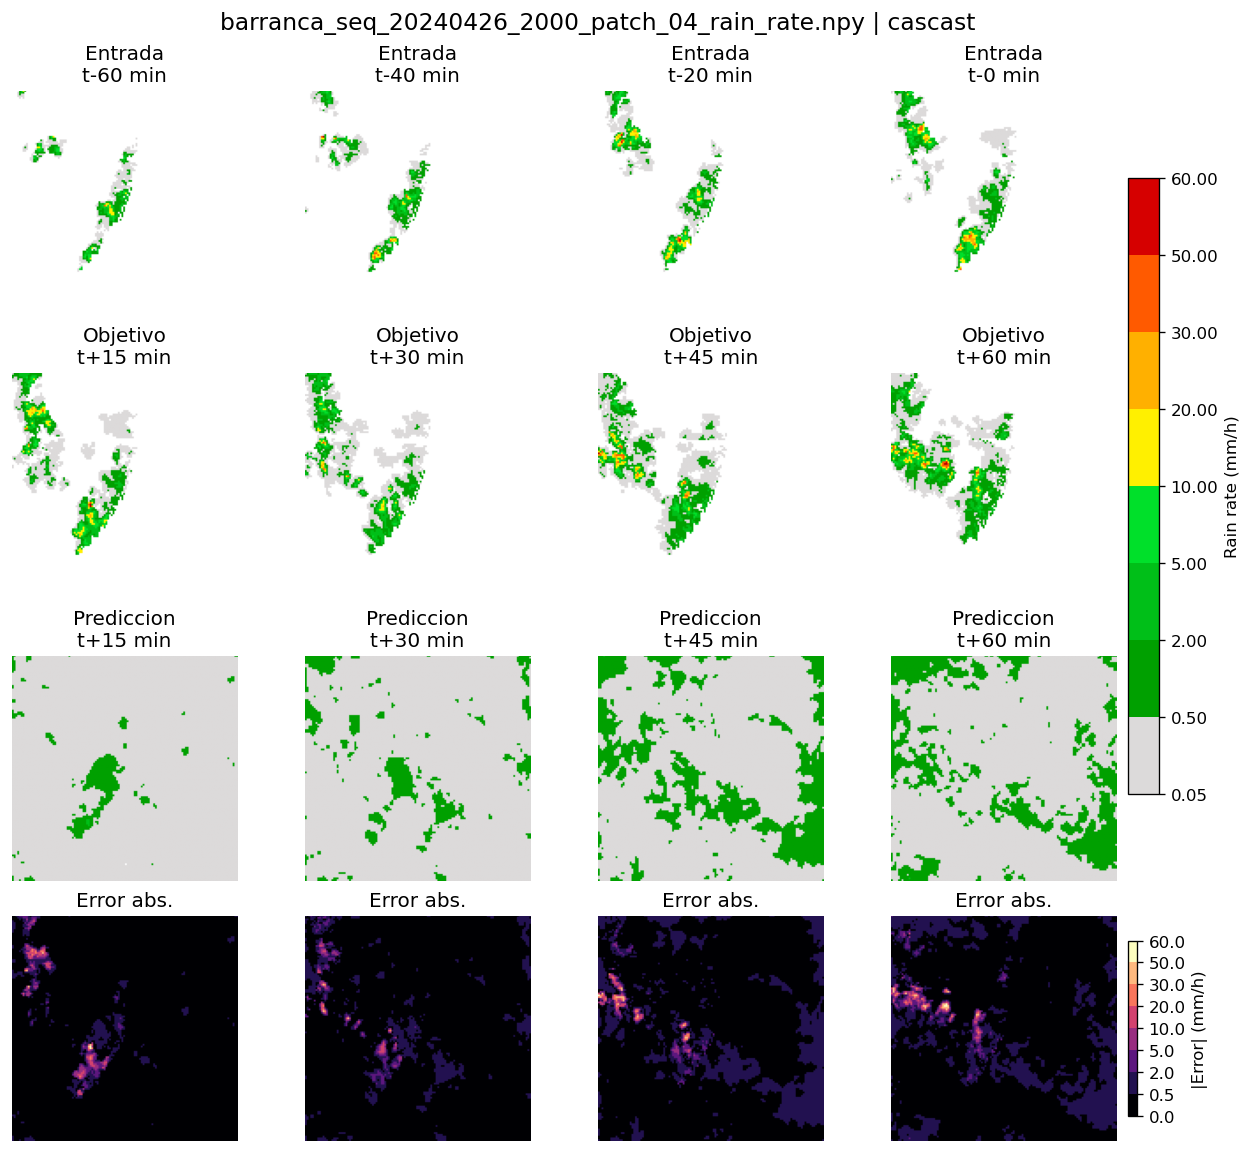

In [7]:
sample_name = SAMPLE_FILES[0]
sequence = load_sample(sample_name, paths)
inputs, target = split_sequence(sequence)
models = available_prediction_models(sample_name, include_persistence=True, paths=paths)
print("Modelos disponibles:", models)

for model_name in models:
    pred = load_prediction_for_model(sample_name, inputs, model_name, paths)
    fig = plot_event_grid(inputs, target, pred, sample_name, model_name, lead_indices=(2, 5, 8, 11))
    plt.show()

## 8. Panel compacto multi-modelo de una secuencia

Una sola figura: cada fila es un modelo, cada columna un tiempo de pronostico, con la misma escala.
Util para ver de un vistazo cual modelo suaviza mas o pierde los nucleos.

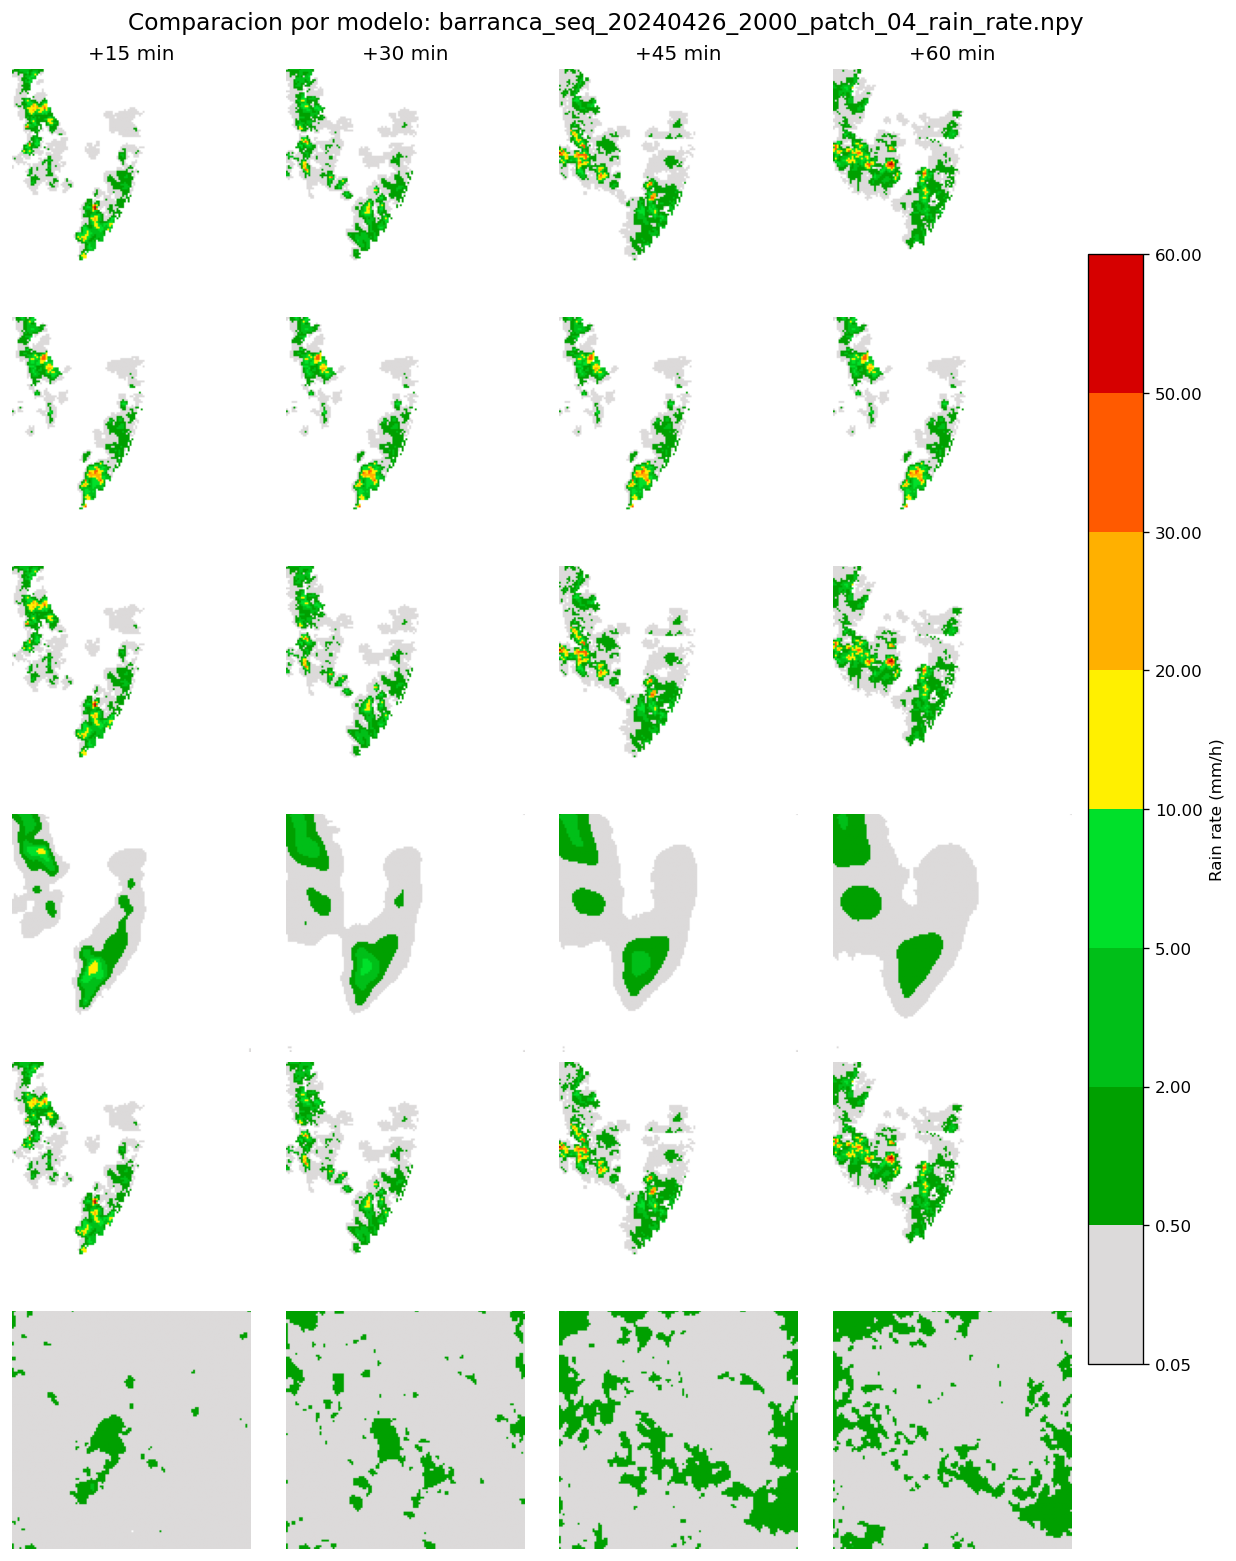

In [8]:
cases = []
for model_name in models:
    pred = load_prediction_for_model(sample_name, inputs, model_name, paths)
    cases.append({"label": model_name, "target": target, "prediction": pred})

fig = plot_target_prediction_panel(cases, title=f"Comparacion por modelo: {sample_name}")
plt.show()

## 9. Metricas de esa misma secuencia

Reutilizamos la tabla `per_file` ya calculada (no recalculamos nada): filtramos las filas de esta
secuencia para acompanar la figura de arriba con numeros.

In [9]:
per_file[per_file["sample"] == sample_name].sort_values("RMSE_mean")

,sample,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_2_mean,CSI_5_mean,CSI_10_mean
1,barranca_seq_20240426_2000_patch_04_rain_rate.npy,earthformer,1.659013,0.247390,-0.089735,0.381944,0.446686,0.260869,0.141444,0.074342
2,barranca_seq_20240426_2000_patch_04_rain_rate.npy,cascast,1.830591,0.499195,0.063812,0.117275,0.150802,0.008394,0.000358,0.000000
0,barranca_seq_20240426_2000_patch_04_rain_rate.npy,persistence,2.171548,0.346029,-0.020286,0.261823,0.398552,0.250179,0.137261,0.087754


## 10. Preguntas para discusion

1. EarthFormer reduce el RMSE frente a persistencia? En que tiempos de pronostico?
2. CasCast cambia el CSI a 5 o 10 mm/h respecto a EarthFormer?
3. Algun modelo se ve mas suave visualmente? Como se relaciona con su CSI intenso?
4. Hay casos donde un modelo mejora la lluvia ligera pero falla la intensa?
5. Que modelo conservarias para una alerta de lluvia fuerte, y por que?